# Data fetching with polytope
Example for how to extract model level data from file/fdb/polytope and create a time-hight plots. Note that fdb is only available on ECMWF atos. To use polytope put your ECMWF web API key, https://api.ecmwf.int/v1/key/ in a ~/.polytopeapirc file as 

{
    "user_key"   : "some_hash",
    "user_email" : "foo.bar@somewhere.ok"
}


In [1]:
# Import necessary libraries
import os
import earthkit.data
import json
import hashlib
from datetime import datetime
from versions import UrbanAirData

In [2]:
# Define your input source as file, fdb or polytope
# Use CUSTOM_FILENAME with full path for file 
version = "9.0"
uad = UrbanAirData().urls[version]

INPUT_SOURCE = "polytope"   # use fdb for extraction on atos, polytope for external usage
CUSTOM_FILENAME = None
CUSTOM_FILEPATH = os.environ.get("SCRATCH", ".")

In [3]:
uad

{'name': 'Paris 9.0',
 'url': 'polytope.ecmwf.int',
 'metadata': {'nx': 989,
  'ny': 989,
  'dx': 500,
  'date': '2023-08-20T15:00:00Z',
  'forecast_range': 'PT36',
  'output_frequency': 'PT15M',
  'fdb': {'expver': 'aagp', 'georef': 'u09tvk'},
  'json': 'json/aagp.json',
  'polytope': {'collection': 'deode', 'url': 'polytope.ecmwf.int'}}}

In [4]:
def load_json(filename):
    with open(filename, "r", encoding="utf-8") as f:
            input_data = json.load(f)
    return input_data

In [5]:
# This loads a table of content per levtype and step
json_data = load_json(uad["metadata"]["json"])

In [6]:
dt = uad["metadata"]["date"]
dt = datetime.strptime(dt, "%Y-%m-%dT%H:%M:%SZ")

In [7]:
# Define the request
request= {
    "class": "d1",
    "dataset": "on-demand-extremes-dt",
    "expver": uad["metadata"]["fdb"]["expver"],
    "stream": "oper",
    "date": dt.strftime("%Y%m%d"),
    "time": dt.strftime("%H%M"),
    "type": "fc",
    "georef": uad["metadata"]["fdb"]["georef"],
    "levtype": "ml",
    "step": 0,
    "levelist": 90,
    "param": 129,
    "timespan": None,
}

In [8]:
def check_fdb_env():
    # Make sure we have the correct FDB environment
    if INPUT_SOURCE == "fdb":
        os.environ["FDB_HOME"] = "/home/fdbtest"
    try:
        os.environ["FDB5_HOME"] = os.environ["ECMWF_TOOLBOX_DIR"]
    except:
        raise KeyError("Make sure to load ecmwf-toolbox before your start")

In [9]:
def construct_filename(request):
   # Construct the filename to cache
    
    key_list = []
    for key,x in request.items():
        if isinstance(x,str):
            key_list.append(x.replace("/","_"))
            #print(f"Add {key}={x}")
        elif isinstance(x,list):
            if any(not isinstance(y, str) for y in x):
               x = [str(y) for y in x]
            combined = "\0".join(x).encode("utf-8")
            hash = hashlib.sha1(combined).hexdigest()[:8]
            key_list.append(hash)
            #print(f"Hashed {key}={hash}")
    filename = "_".join(key_list) + ".grib2"
    data_target_path = f"{CUSTOM_FILEPATH}/{filename}"
    return data_target_path

In [10]:
def request_data(request):
    # Run the request
    print(request)
    data_target_path = construct_filename(request)
    if not os.path.isfile(data_target_path):
        if INPUT_SOURCE == "polytope":
            from polytope.api import Client
            client = Client(address=uad["metadata"]["polytope"]["url"])
            data = earthkit.data.from_source("polytope", uad["metadata"]["polytope"]["collection"], request, address=uad["metadata"]["polytope"]["url"], stream=False)
        elif INPUT_SOURCE == "fdb":
            check_fdb_env()
            data = earthkit.data.from_source("fdb", request, read_all=True)
        print("Save data to:", data_target_path)
        data.to_target("file", data_target_path)
    else:
        if CUSTOM_FILENAME is not None:
            data_target_path = CUSTOM_FILENAME
        print("Read:", data_target_path)
        data = earthkit.data.from_source("file", data_target_path)
    return data

In [11]:
def plot_map(x):
 chart = earthkit.plots.Map()
 chart.quickplot(x)
 chart.coastlines()
 chart.land()
 chart.borders()
 chart.gridlines()
 try:
    chart.legend()
 except:
    pass
 chart.show()

In [12]:
data = request_data(request)
data.ls()

{'class': 'd1', 'dataset': 'on-demand-extremes-dt', 'expver': 'aagp', 'stream': 'oper', 'date': '20230820', 'time': '1500', 'type': 'fc', 'georef': 'u09tvk', 'levtype': 'ml', 'step': 0, 'levelist': 90, 'param': 129, 'timespan': None}


2026-06-10 20:26:59 - INFO - Key read from /home/a000864/.polytopeapirc
2026-06-10 20:26:59 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: on-demand-extremes-dt\n'
            "date: '20230820'\n"
            'expver: aagp\n'
            'georef: u09tvk\n'
            'levelist: 90\n'
            'levtype: ml\n'
            'param: 129\n'
            'step: 0\n'
            'stream: oper\n'
            "time: '1500'\n"
            'timespan: null\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-10 20:26:59 - INFO - Polytope user key found in session cache for user a000864
2026-06-10 20:26:59 - INFO - Request accepted. Please poll ./d18487dc-ed88-4529-ad95-17be24ade757 for status
2026-06-10 20:26:59 - INFO - Polytope user key found in session cache for user a000864
2026-06-10 20:26:59 - INFO - Checking request status (d18487dc-ed88-4529-ad95-17be24ade757)...
2026-06-10 20:27:00 - INFO - The current status of the request is 'queued'
2026-06-10 20:27:

Save data to: ./d1_on-demand-extremes-dt_aagp_oper_20230820_1500_fc_u09tvk_ml.grib2


,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,z,hybrid,90,20230820,1500,0s,fc,None,lambert_lam


In [13]:
# Extract A/B half levels from first GRIB message
a_and_b  = data.metadata("pv")[0]
l = len(a_and_b)//2
ahalf, bhalf = a_and_b[:l], a_and_b[l:]

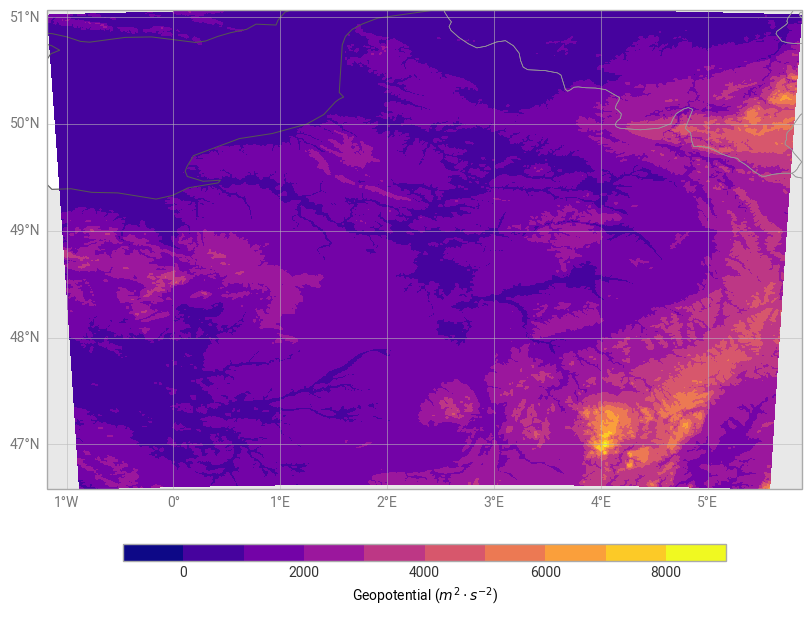

In [14]:
plot_map(data[0])